<a href="https://colab.research.google.com/github/Ideas360/Talentechinno/blob/main/Act_2_Redes_Neu.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

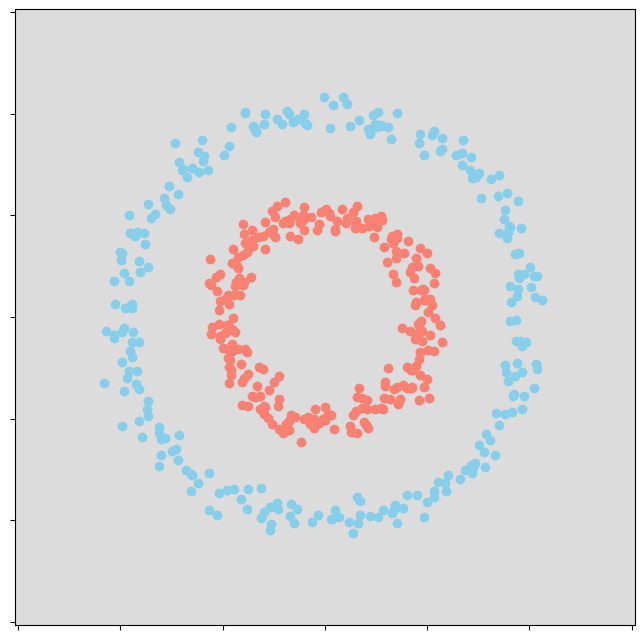

In [ ]:
import numpy as np
import scipy as sc
import matplotlib.pyplot as plt

from sklearn.datasets import make_circles

# Creamos nuestros datos artificiales, donde buscaremos clasificar
# dos anillos concéntricos de datos.
X, Y = make_circles(n_samples=500, factor=0.5, noise=0.05)

# Resolución del mapa de predicción.
res = 100

# Coordenadas del mapa de predicción.
_x0 = np.linspace(-1.5, 1.5, res)
_x1 = np.linspace(-1.5, 1.5, res)

# Input con cada combo de coordenadas del mapa de predicción.
_pX = np.array(np.meshgrid(_x0, _x1)).T.reshape(-1, 2)

# Objeto vacío a 0.5 del mapa de predicción.
_pY = np.zeros((res, res)) + 0.5

# Visualización del mapa de predicción.
plt.figure(figsize=(8, 8))
plt.pcolormesh(_x0, _x1, _pY, cmap="coolwarm", vmin=0, vmax=1)

# Visualización de la nube de datos.
plt.scatter(X[Y == 0,0], X[Y == 0,1], c="skyblue")
plt.scatter(X[Y == 1,0], X[Y == 1,1], c="salmon")

plt.tick_params(labelbottom=False, labelleft=False)


step 0 / 350 . Loss =  0.49666142 . Acc = 0.398
step 25 / 350 . Loss =  0.17979906 . Acc = 0.756
step 50 / 350 . Loss =  0.14493845 . Acc = 0.882
step 75 / 350 . Loss =  0.13287793 . Acc = 0.908
step 100 / 350 . Loss =  0.12459282 . Acc = 0.916
step 125 / 350 . Loss =  0.1185355 . Acc = 0.918
step 150 / 350 . Loss =  0.11299395 . Acc = 0.92
step 175 / 350 . Loss =  0.1077087 . Acc = 0.926
step 200 / 350 . Loss =  0.10276247 . Acc = 0.93
step 225 / 350 . Loss =  0.09735934 . Acc = 0.938
step 250 / 350 . Loss =  0.09121465 . Acc = 0.946
step 275 / 350 . Loss =  0.0831282 . Acc = 0.956
step 300 / 350 . Loss =  0.07399266 . Acc = 0.972
step 325 / 350 . Loss =  0.06481333 . Acc = 0.984
Generando animación ----


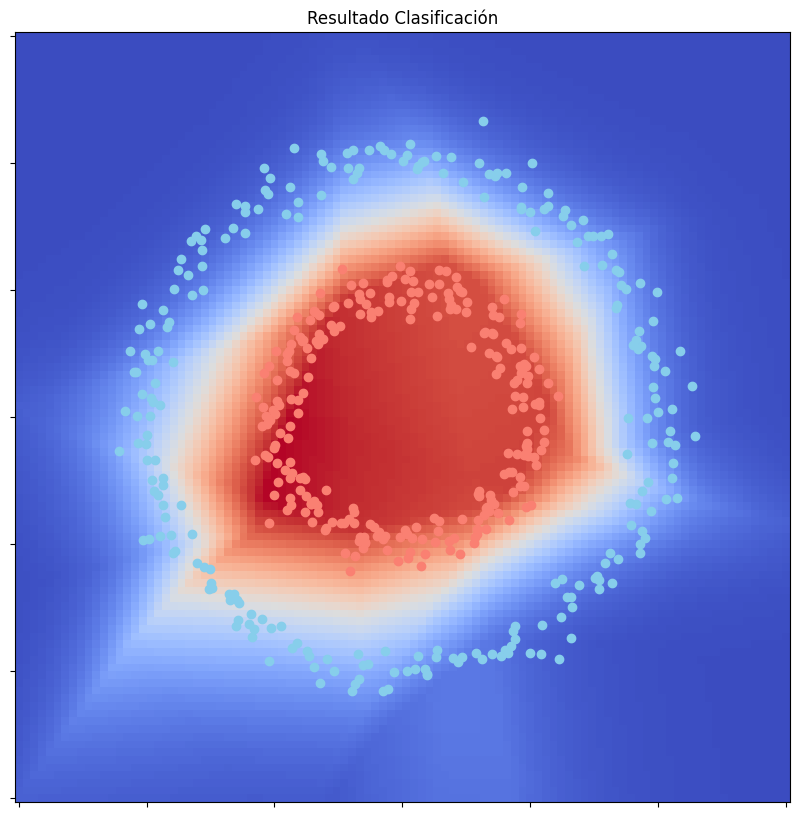

In [ ]:
#import tensorflow as tf
import tensorflow.compat.v1 as tf
tf.disable_v2_behavior()

from matplotlib import animation
from IPython.core.display import display, HTML

# Definimos los puntos de entrada de la red, para la matriz x e Y.
iX = tf.placeholder('float', shape=[None, X.shape[1]])
iY = tf.placeholder('float', shape=[None])

lr = 0.01                  # learning rate
nn = [2, 16, 8, 1]         # número de neuronas por capa.

# Capa 1
w1 = tf.Variable(tf.random_normal([nn[0], nn[1]]), name='Weights_1')
b1 = tf.Variable(tf.random_normal([nn[1]]), name='bias_1')
l1 = tf.nn.relu(tf.add(tf.matmul(iX, w1), b1))

# Capa 2
w2 = tf.Variable(tf.random_normal([nn[1], nn[2]]), name='Weights_2')
b2 = tf.Variable(tf.random_normal([nn[2]]), name='bias_2')
l2 = tf.nn.relu(tf.add(tf.matmul(l1, w2), b2))

# Capa 3
w3 = tf.Variable(tf.random_normal([nn[2], nn[3]]), name='Weights_3')
b3 = tf.Variable(tf.random_normal([nn[3]]), name='bias_3')
# Vector de las predicciones de Y.
pY = tf.nn.sigmoid(tf.add(tf.matmul(l2, w3), b3))[:, 0]

# Evaluación de las predicciones.
loss = tf.losses.mean_squared_error(pY, iY)

# Definimos al optimizador de la red, para que minimice el error.
optimizer = tf.train.GradientDescentOptimizer(learning_rate=0.05).minimize(loss)
n_steps = 350  # Número de ciclos de entrenamiento.
iPY = []  # Aquí guardaremos la evolución de la predicción, para la animación.

with tf.Session() as sess:
    # Inicializamos todos los parámetros de la red, las matrices W y b.
    sess.run(tf.global_variables_initializer())
    # Iteramos en pasos de entrenamiento.
    for step in range(n_steps):
        # Se entrena al optimizador, a la función de coste y al tensor de salida pY.
        _, _loss = sess.run([optimizer, loss], feed_dict={ iX : X, iY : Y })
        # Cada 25 iteraciones, imprimimos métricas.
        if step % 25 == 0:
            # Cálculo del accuracy.
            _pY_pred = sess.run(pY, feed_dict={ iX : X })
            acc = np.mean(np.round(_pY_pred) == Y)
            # Impresión de métricas.
            print('step', step, '/', n_steps, '. Loss = ', _loss, '. Acc =', acc)
        # Obtenemos predicciones para cada punto de nuestro mapa de predicción _pX.
        _pY = sess.run(pY, feed_dict={ iX : _pX }).reshape((res, res))
        # Lo guardamos para visualizar la animación.
        iPY.append(_pY)

# ------ CÓDIGO ANIMACIÓN ------ #
ims = []
fig = plt.figure(figsize=(10, 10))
print('Generando animación ----')

for fr in range(len(iPY)):
    im = plt.pcolormesh(_x0, _x1, iPY[fr], cmap="coolwarm", animated=True)
    # Visualización de la nube de datos.
    plt.scatter(X[Y == 0, 0], X[Y == 0, 1], c="skyblue")
    plt.scatter(X[Y == 1, 0], X[Y == 1, 1], c="salmon")
    plt.title("Resultado Clasificación")
    plt.tick_params(labelbottom=False, labelleft=False)
    ims.append([im])
ani = animation.ArtistAnimation(fig, ims, interval=50, blit=True, repeat_delay=1000)
HTML(ani.to_html5_video())